In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

Task 1

In [6]:
df = pd.read_csv("heart_disease.csv")
df.shape

(270, 14)

In [ ]:
df.head()
'''
Looking at the target column, it is binary for if patient did or did not have heart disease. Binary
classification fits this set. We can tell because its either did or did not have heart disease.
'''

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


Task 2

In [ ]:
df['target'].value_counts()

#for a model that predicted no for every patient, it would have been correct for 55% of the patients.

#This is a bad flag because almost a 50/50 for a life threatening condition, and they would be missing
#several people with heart disease.

target
0    150
1    120
Name: count, dtype: int64

Task 3

In [8]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X test", X_test.shape)
print("X train", X_train.shape)
print("y test", y_test.shape)
print("y train", y_train.shape)

X test (54, 13)
X train (216, 13)
y test (54,)
y train (216,)


Task 4

In [15]:
lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train, y_train)
lr_predicts = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predicts)
print(f"Logistic Regression model Accuracy: {lr_accuracy}")

Logistic Regression model Accuracy: 0.9259259259259259


In [ ]:
# The lazy "always no" provided a 55% where as our lr model gave a 92% accuracy rate. The model is 
# performing better than the lazy model.

Task 6

In [ ]:
dt_model_nolimit = DecisionTreeClassifier(max_depth=None)

dt_model_nolimit.fit(X_train, y_train)
dt_nolimit_pred = dt_model_nolimit.predict(X_test)
dt_nolimit = accuracy_score(y_test, dt_nolimit_pred)
dt_nolimit_train = dt_model_nolimit.score(X_train, y_train)

print(f"Accuracy for DT with no limits: {dt_nolimit}")
print(f"Accuracy for DT w/o limits training data: {dt_nolimit_train}")
dt_model_limit = DecisionTreeClassifier(max_depth=4)

dt_model_limit.fit(X_train, y_train)
dt_limit_pred = dt_model_limit.predict(X_test)
dt_limit = accuracy_score(y_test, dt_limit_pred)
dt_limit_train = dt_model_limit.score(X_train, y_train)

print(f"Accuracy for DT w/limits training data: {dt_limit_train}")
print(f"Accuracy for DT with limits: {dt_limit}")


Accuracy for DT with no limits: 0.7037037037037037
Accuracy for DT w/o limits training data: 1.0
Accuracy for DT w/limits training data: 0.8935185185185185
Accuracy for DT with limits: 0.8333333333333334


In [ ]:
# DT without limits scored perfectly on training data but not as well on the test data.

# Overfitting to the training data skews predictions on data never seen before.

Task 7

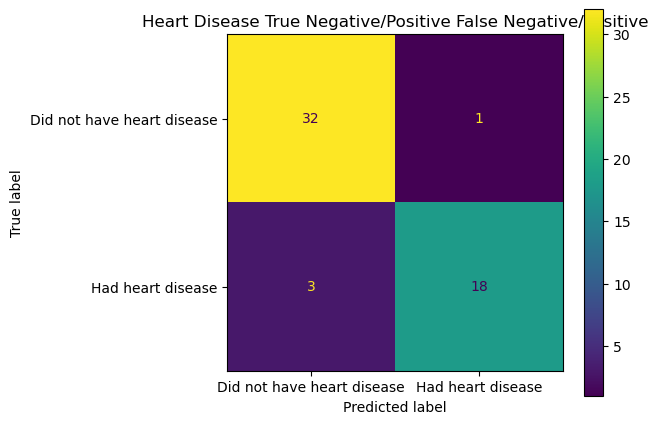

In [23]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predicts,
    display_labels=["Did not have heart disease", "Had heart disease"]
)

plt.title("Heart Disease True Negative/Positive False Negative/Positive")
plt.tight_layout()
plt.show()

In [ ]:
# index [1,0] "3" patients were said to be healthy but actually had heart disease. 

# This is the most dangerous cell for the clinic because missing heart disease can be very fatal. 